In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc

In [2]:
fichier= "Jasgulem_core_2025.xlsx"

onglet_iso = "h2o_iso"
onglet_density = "density"
onglet_ice = "ice_layers"
onglet_chem = "chemistry"
onglet_accuscen = "accu_scenario"


In [3]:
df = pd.read_excel(fichier, sheet_name=onglet_iso)
df_dens = pd.read_excel(fichier, sheet_name=onglet_density)
df_ice = pd.read_excel(fichier, sheet_name=onglet_ice)
df_scenaccu = pd.read_excel(fichier, sheet_name=onglet_accuscen)
df_chem = pd.read_excel(fichier, sheet_name=onglet_chem)

#### Functions

In [4]:
def make_step_segments(df, col, top_col, bottom_col):
    segments = []
    values, depths = [], []

    for i in range(len(df)):
        val = df.iloc[i][col]
        top = df.iloc[i][top_col]
        bottom = df.iloc[i][bottom_col]

        if pd.isna(val):
            # rupture sur valeur manquante
            if values:
                segments.append((values, depths))
                values, depths = [], []
            continue

        # Ajouter le segment du point courant
        values.extend([val, val])
        depths.extend([top, bottom])

        # Vérifier la continuité de profondeur
        if i < len(df) - 1:
            next_top = df.iloc[i + 1][top_col]
            if bottom != next_top:
                # discontinuité → couper ici
                segments.append((values, depths))
                values, depths = [], []

    # Finaliser le dernier segment
    if values:
        segments.append((values, depths))

    return segments

## WATER ISOTOPES

## Plot data on uncorrected depth scale

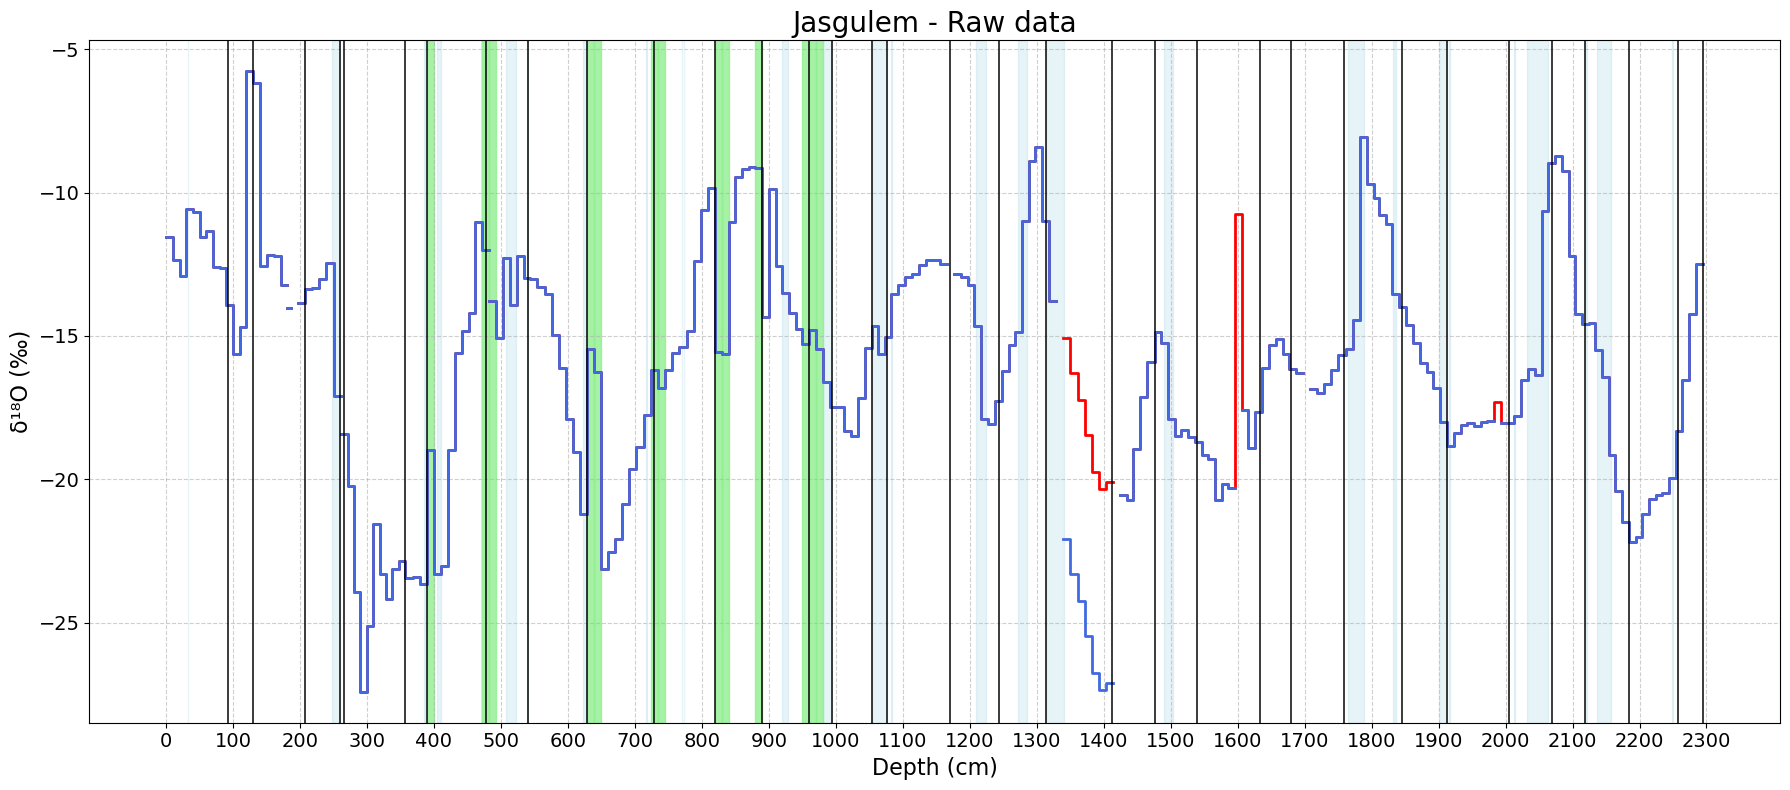

In [5]:
# === Nettoyage des colonnes ===
df.columns = df.columns.str.strip()
df_ice.columns = df_ice.columns.str.strip()

# === Génération des segments ===
segments_o = make_step_segments(df, "Calibrated d(18_16) Mean", "Uncorrected top depth","Uncorrected bottom depth" )
segments_shift = make_step_segments(df, "Shifted Calibrated d(18_16) Mean","Uncorrected top depth","Uncorrected bottom depth" )

# === 5. Tracé ===
plt.figure(figsize=(18, 8))
ax = plt.gca()

# ------------------------------
#  Bandes BLEUES (glace)
# # ------------------------------
for _, row in df_ice.iterrows():
    top = row["Uncorrected top depth"]
    bottom = row["Uncorrected bottom depth"]
    if pd.notna(top) and pd.notna(bottom) and bottom > top:
        ax.axvspan(top, bottom, color="lightblue", alpha=0.30, zorder=0)

# ------------------------------
#  Bandes VERTES (Copeaux, Flag_Chips = 1)
# ------------------------------

for _, row in df.iterrows():
    if row.get("Flag_Chips") == 1.0:
        top = row["Uncorrected top depth"]
        bottom = row["Uncorrected bottom depth"]
        # if bottom > top:
        ax.axvspan(top, bottom, color="lightgreen", alpha=0.8, zorder=1)

# ------------------------------
#  Courbes SHIFTED (rouge) et d18O (bleu)
# ------------------------------

for values, depths in segments_shift:
    ax.plot(depths, values, color="red", linewidth=2, zorder=2, label="Shifted δ18O")

for values, depths in segments_o:
    ax.plot(depths, values, color="royalblue", linewidth=2, zorder=3, label="δ18O")

# ------------------------------
#  Traits noirs VERTICAUX aux limites de RUN
# ------------------------------
for _, row in df.iterrows():
    if pd.notna(row.get("Run lenght")) and row["Run lenght"] != "":
        bottom = row["Core lenght"]
        ax.axvline(bottom, color="black", linewidth=1.2, alpha=0.9, zorder=5)

# === Mise en forme ===
ax.set_xlabel("Depth (cm)", fontsize=16)
ax.set_ylabel("δ¹⁸O (‰)", fontsize=16)
ax.set_title("Jasgulem - Raw data", fontsize=20)

xmax = df["Uncorrected bottom depth"].max()
ax.set_xticks(np.arange(0, xmax + 100, 100))

ax.tick_params(axis='both', labelsize=14)
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## Plot data on corrected depth scale

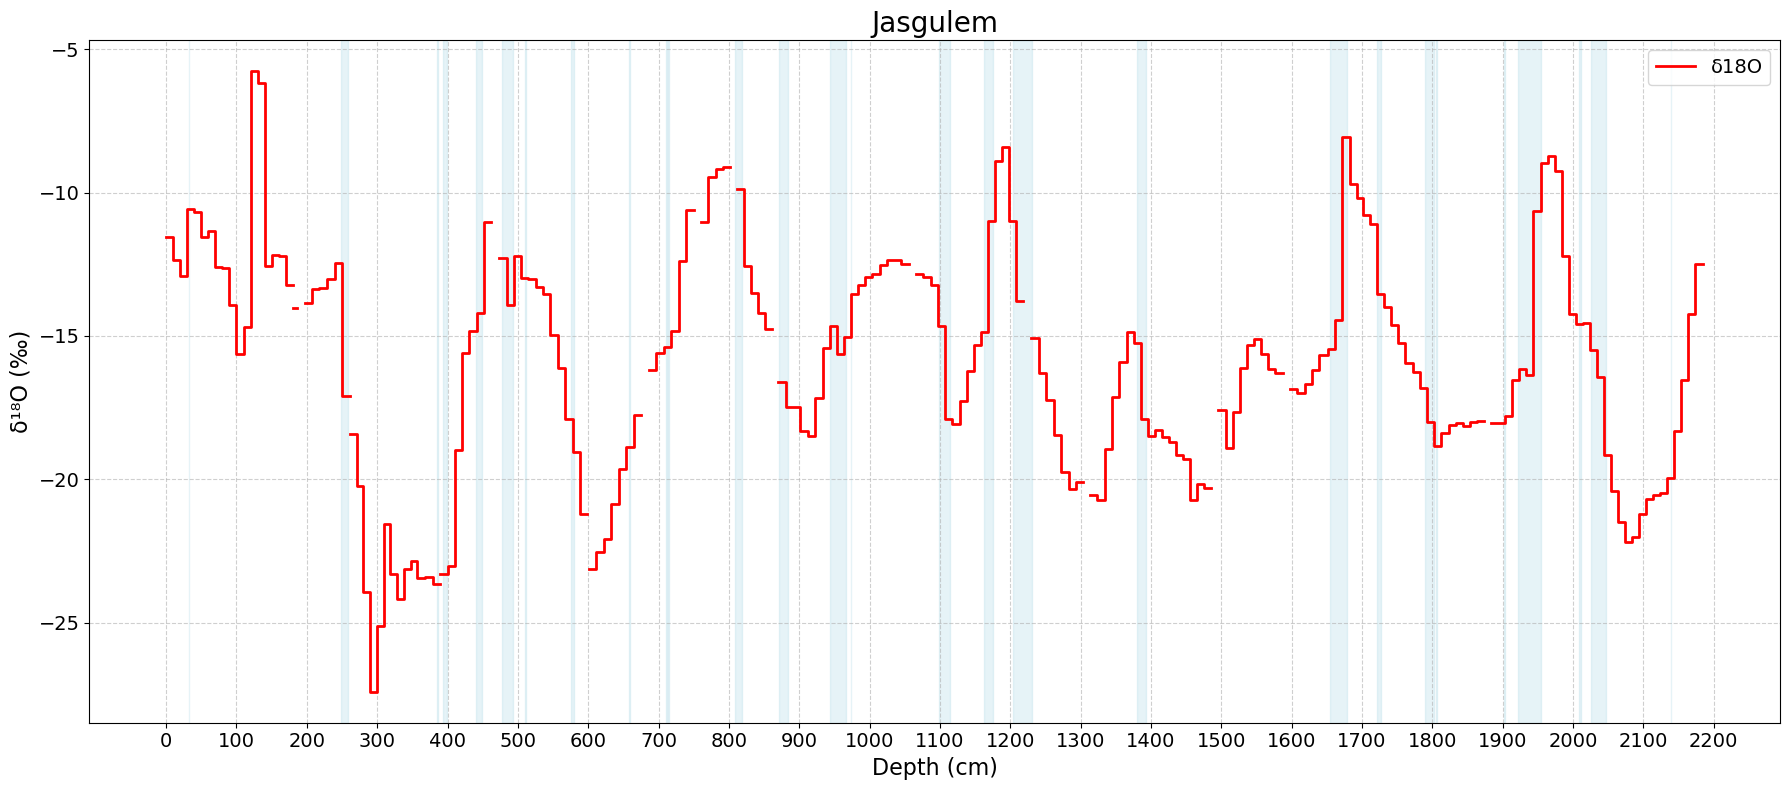

In [6]:
df = df.dropna(subset=["Top depth", "Bottom depth"])
df.reset_index(drop=True, inplace=True)

segments = make_step_segments(df, "Corrected Calibrated d(18_16) Mean", "Top depth", "Bottom depth")

#Tracé ===
plt.figure(figsize=(18, 8))
ax = plt.gca()

# ------------------------------
#  Bandes BLEUES : ICE
# ------------------------------
for _, row in df_ice.iterrows():
    top = row["Top depth"]
    bottom = row["Bottom depth"]
    if pd.notna(top) and pd.notna(bottom) and bottom > top:
        ax.axvspan(top, bottom, color="lightblue", alpha=0.30, zorder=0)

# ------------------------------
#  Courbe d18O 
# ------------------------------
for values, depths in segments:
    ax.plot(depths, values, color="red", linewidth=2, zorder=3, label="δ18O")

# === Légende ===
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), fontsize=14)

# === Mise en forme ===
ax.set_xlabel("Depth (cm)", fontsize=16)
ax.set_ylabel("δ¹⁸O (‰)", fontsize=16)
ax.set_title("Jasgulem", fontsize=20)

xmax = df["Bottom depth"].max()
ax.set_xticks(np.arange(0, xmax + 100, 100))

ax.tick_params(axis='both', labelsize=14)
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# DENSITY

In [7]:
df = df.dropna(subset=["Top depth", "Bottom depth"])
df.reset_index(drop=True, inplace=True)

df_dens = df_dens.dropna(subset=["Top depth", "Bottom depth"])
df_dens.reset_index(drop=True, inplace=True)

In [8]:
segments_iso = make_step_segments(df, "Corrected Calibrated d(18_16) Mean", "Top depth", "Bottom depth")
segments_dens = make_step_segments(df_dens, "density", "Top depth", "Bottom depth")

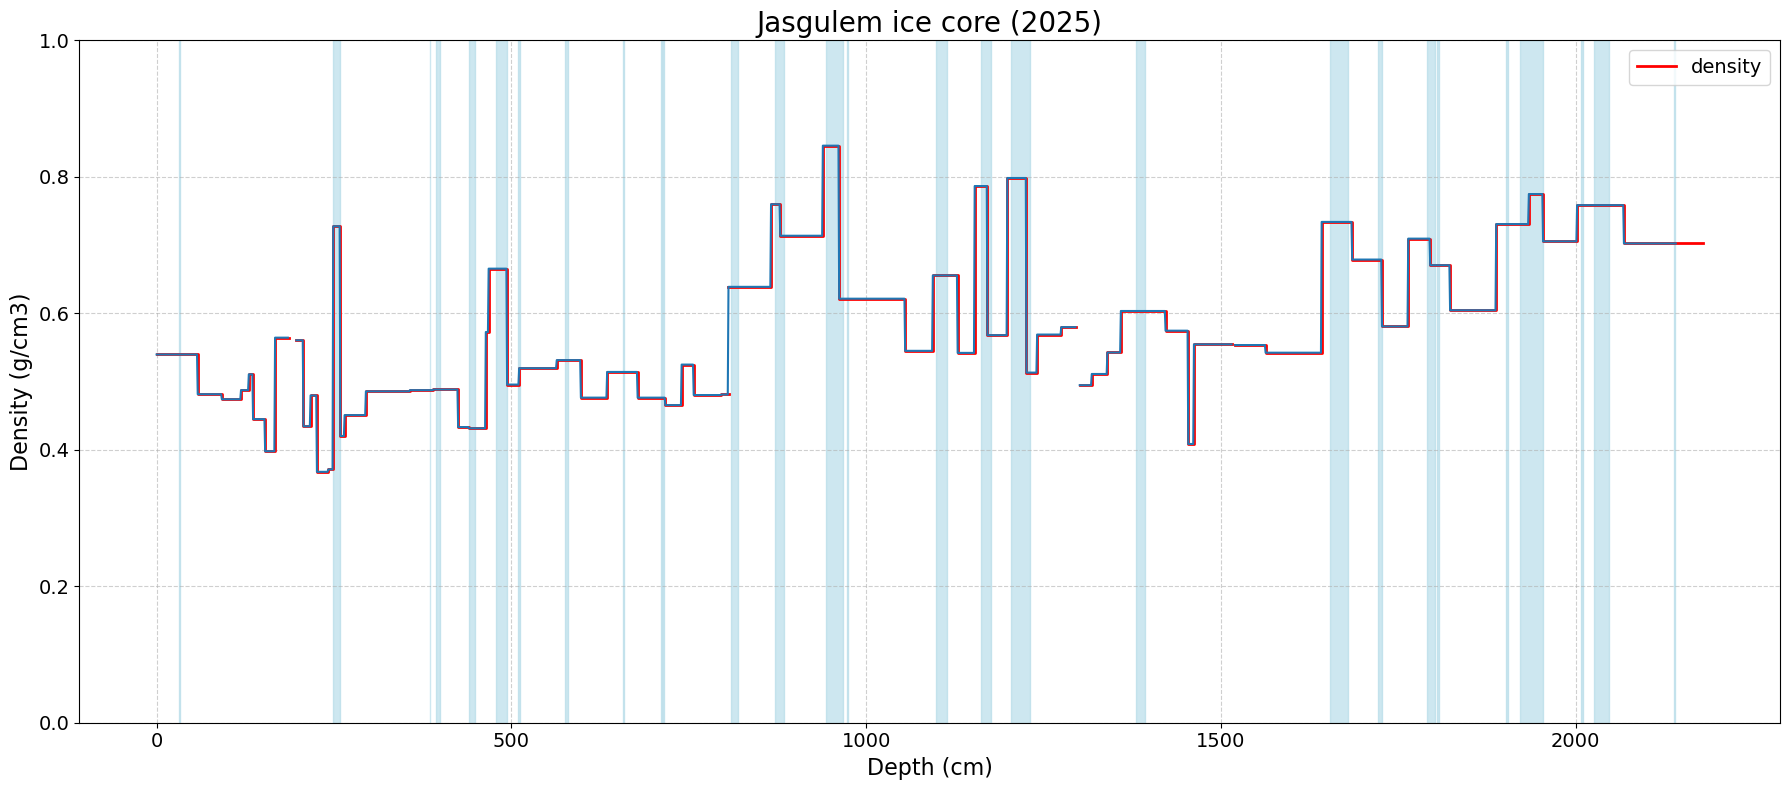

In [12]:
plt.figure(figsize=(18, 8))
ax = plt.gca()

# ------------------------------
#  Courbe Densité
# ------------------------------
first_shift = True
for values, depths in segments_dens:
    ax.plot(depths, values, color="red", linewidth=2,
            label="density" if first_shift else "")
    first_shift = False

ax.plot(depth_1cm,dens_1cm)
# ------------------------------
#  Bandes BLEUES : ICE
# ------------------------------
for _, row in df_ice.iterrows():
    top = row["Top depth"]
    bottom = row["Bottom depth"]
    if pd.notna(top) and pd.notna(bottom) and bottom > top:
        ax.axvspan(top, bottom, color="lightblue", alpha=0.60, zorder=0)

# === Légende ===
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), fontsize=14)

# === Mise en forme ===
ax.set_xlabel("Depth (cm)", fontsize=16)
ax.set_ylabel("Density (g/cm3)", fontsize=16)
ax.set_title("Jasgulem ice core (2025)", fontsize=20)
ax.set_ylim(0, 1)

ax.tick_params(axis='both', labelsize=14)
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

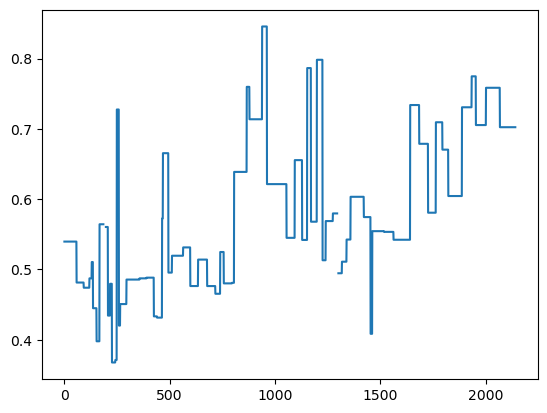

In [11]:
#Interpolate Density data at 1cm resolution, and save in df_dens_1cm 

x=df_dens["Top depth"]
y=df_dens["density"]
f = sc.interpolate.interp1d(x,y,kind="previous")

depth_1cm = np.arange(min(df_dens["Top depth"]), max(df_dens["Top depth"]), 1)
dens_1cm = f(depth_1cm)

df_dens_1cm = pd.DataFrame({
    "depth": depth_1cm,
    "density": dens_1cm
})

#Show interpolated data
plt.plot(depth_1cm,dens_1cm)

In [13]:
def accu_between(z1, z2, df):
    mask = (df['depth'] >= z1) & (df['depth'] < z2) 
    sub = df[mask]
    mean_density = sub["density"].sum()/100
    return mean_density

In [14]:
df_scenaccu['accu_1'] = 0
df_scenaccu['accu_2'] = 0

In [15]:
for i in range(1, len(df_scenaccu)):
    df_scenaccu.loc[i, 'accu_1'] = accu_between(df_scenaccu.loc[i-1, 'depth_1'],df_scenaccu.loc[i, 'depth_1'], df_dens_1cm)

for i in range(1, len(df_scenaccu)):
    df_scenaccu.loc[i, 'accu_2'] = accu_between(df_scenaccu.loc[i-1, 'depth_2'],df_scenaccu.loc[i, 'depth_2'], df_dens_1cm)

/tmp/ipykernel_3647/3159519279.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.415092178523295' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scenaccu.loc[i, 'accu_1'] = accu_between(df_scenaccu.loc[i-1, 'depth_1'],df_scenaccu.loc[i, 'depth_1'], df_dens_1cm)
/tmp/ipykernel_3647/3159519279.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.415092178523295' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scenaccu.loc[i, 'accu_2'] = accu_between(df_scenaccu.loc[i-1, 'depth_2'],df_scenaccu.loc[i, 'depth_2'], df_dens_1cm)


In [16]:
#df_scenaccu.to_csv("Jasgulem_scen_accu.txt", sep="\t", index=False)
df_scenaccu

,summer,depth_1,depth_2,accu_1,accu_2
0,2025-2026,0,0.0,0.000000,0.000000
1,2024-2025,500,500.0,2.415092,2.415092
2,2023-2024,790,790.0,1.448345,1.448345
3,2022-2023,1040,1040.0,1.666311,1.666311
4,2021-2022,1190,1190.0,0.914733,0.914733
5,2020-2021,1375,1375.0,1.054880,1.054880
6,2019-2020,1550,1690.0,0.965560,1.815409
7,2018-2019,1690,1960.0,0.849849,1.799922
8,2017-2018,1960,NaN,1.799922,0.000000


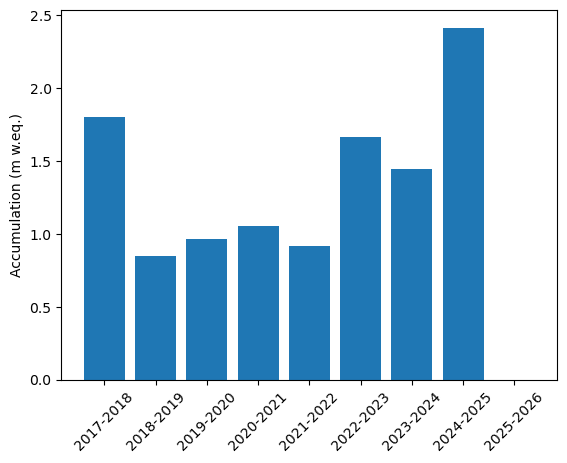

In [17]:
plt.figure()

plt.bar(df_scenaccu["summer"], df_scenaccu["accu_1"])
plt.ylabel("Accumulation (m w.eq.)")
#plt.title("Scenario 1")
plt.xticks(rotation=45)
plt.xticks(df_scenaccu["summer"], rotation=45)
plt.gca().invert_xaxis()

plt.show()

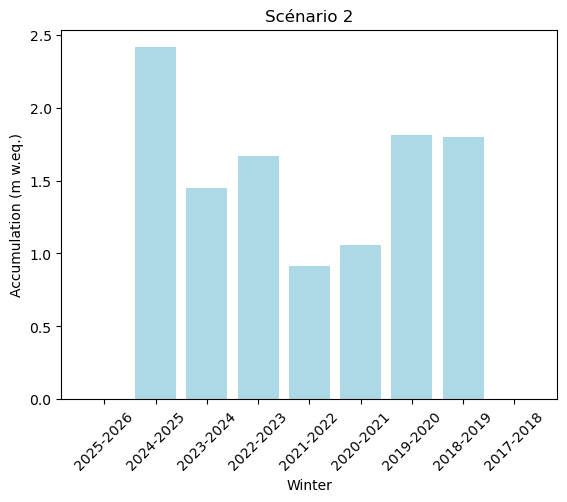

In [18]:
plt.figure()

plt.bar(df_scenaccu["summer"], df_scenaccu["accu_2"], color='lightblue')
plt.xlabel("Winter")
plt.ylabel("Accumulation (m w.eq.)")
plt.title("Scénario 2")
plt.xticks(df_scenaccu["summer"], rotation=45)
plt.xticks(rotation=45)

plt.show()

## CHEMISTRY

In [19]:
df = pd.read_excel(fichier, sheet_name=onglet_iso)
df_dens = pd.read_excel(fichier, sheet_name=onglet_density)
df_ice = pd.read_excel(fichier, sheet_name=onglet_ice)
df_scenaccu = pd.read_excel(fichier, sheet_name=onglet_accuscen)
df_chem = pd.read_excel(fichier, sheet_name=onglet_chem)

In [20]:
df = df.dropna(subset=["Top depth", "Bottom depth"])
df.reset_index(drop=True, inplace=True)

In [21]:
df_chem = df_chem.dropna(subset=["Top depth", "Bottom depth"])
df_chem.reset_index(drop=True, inplace=True)

df_chem = df_chem.apply(pd.to_numeric, errors='coerce') # replace n.a. with NaN

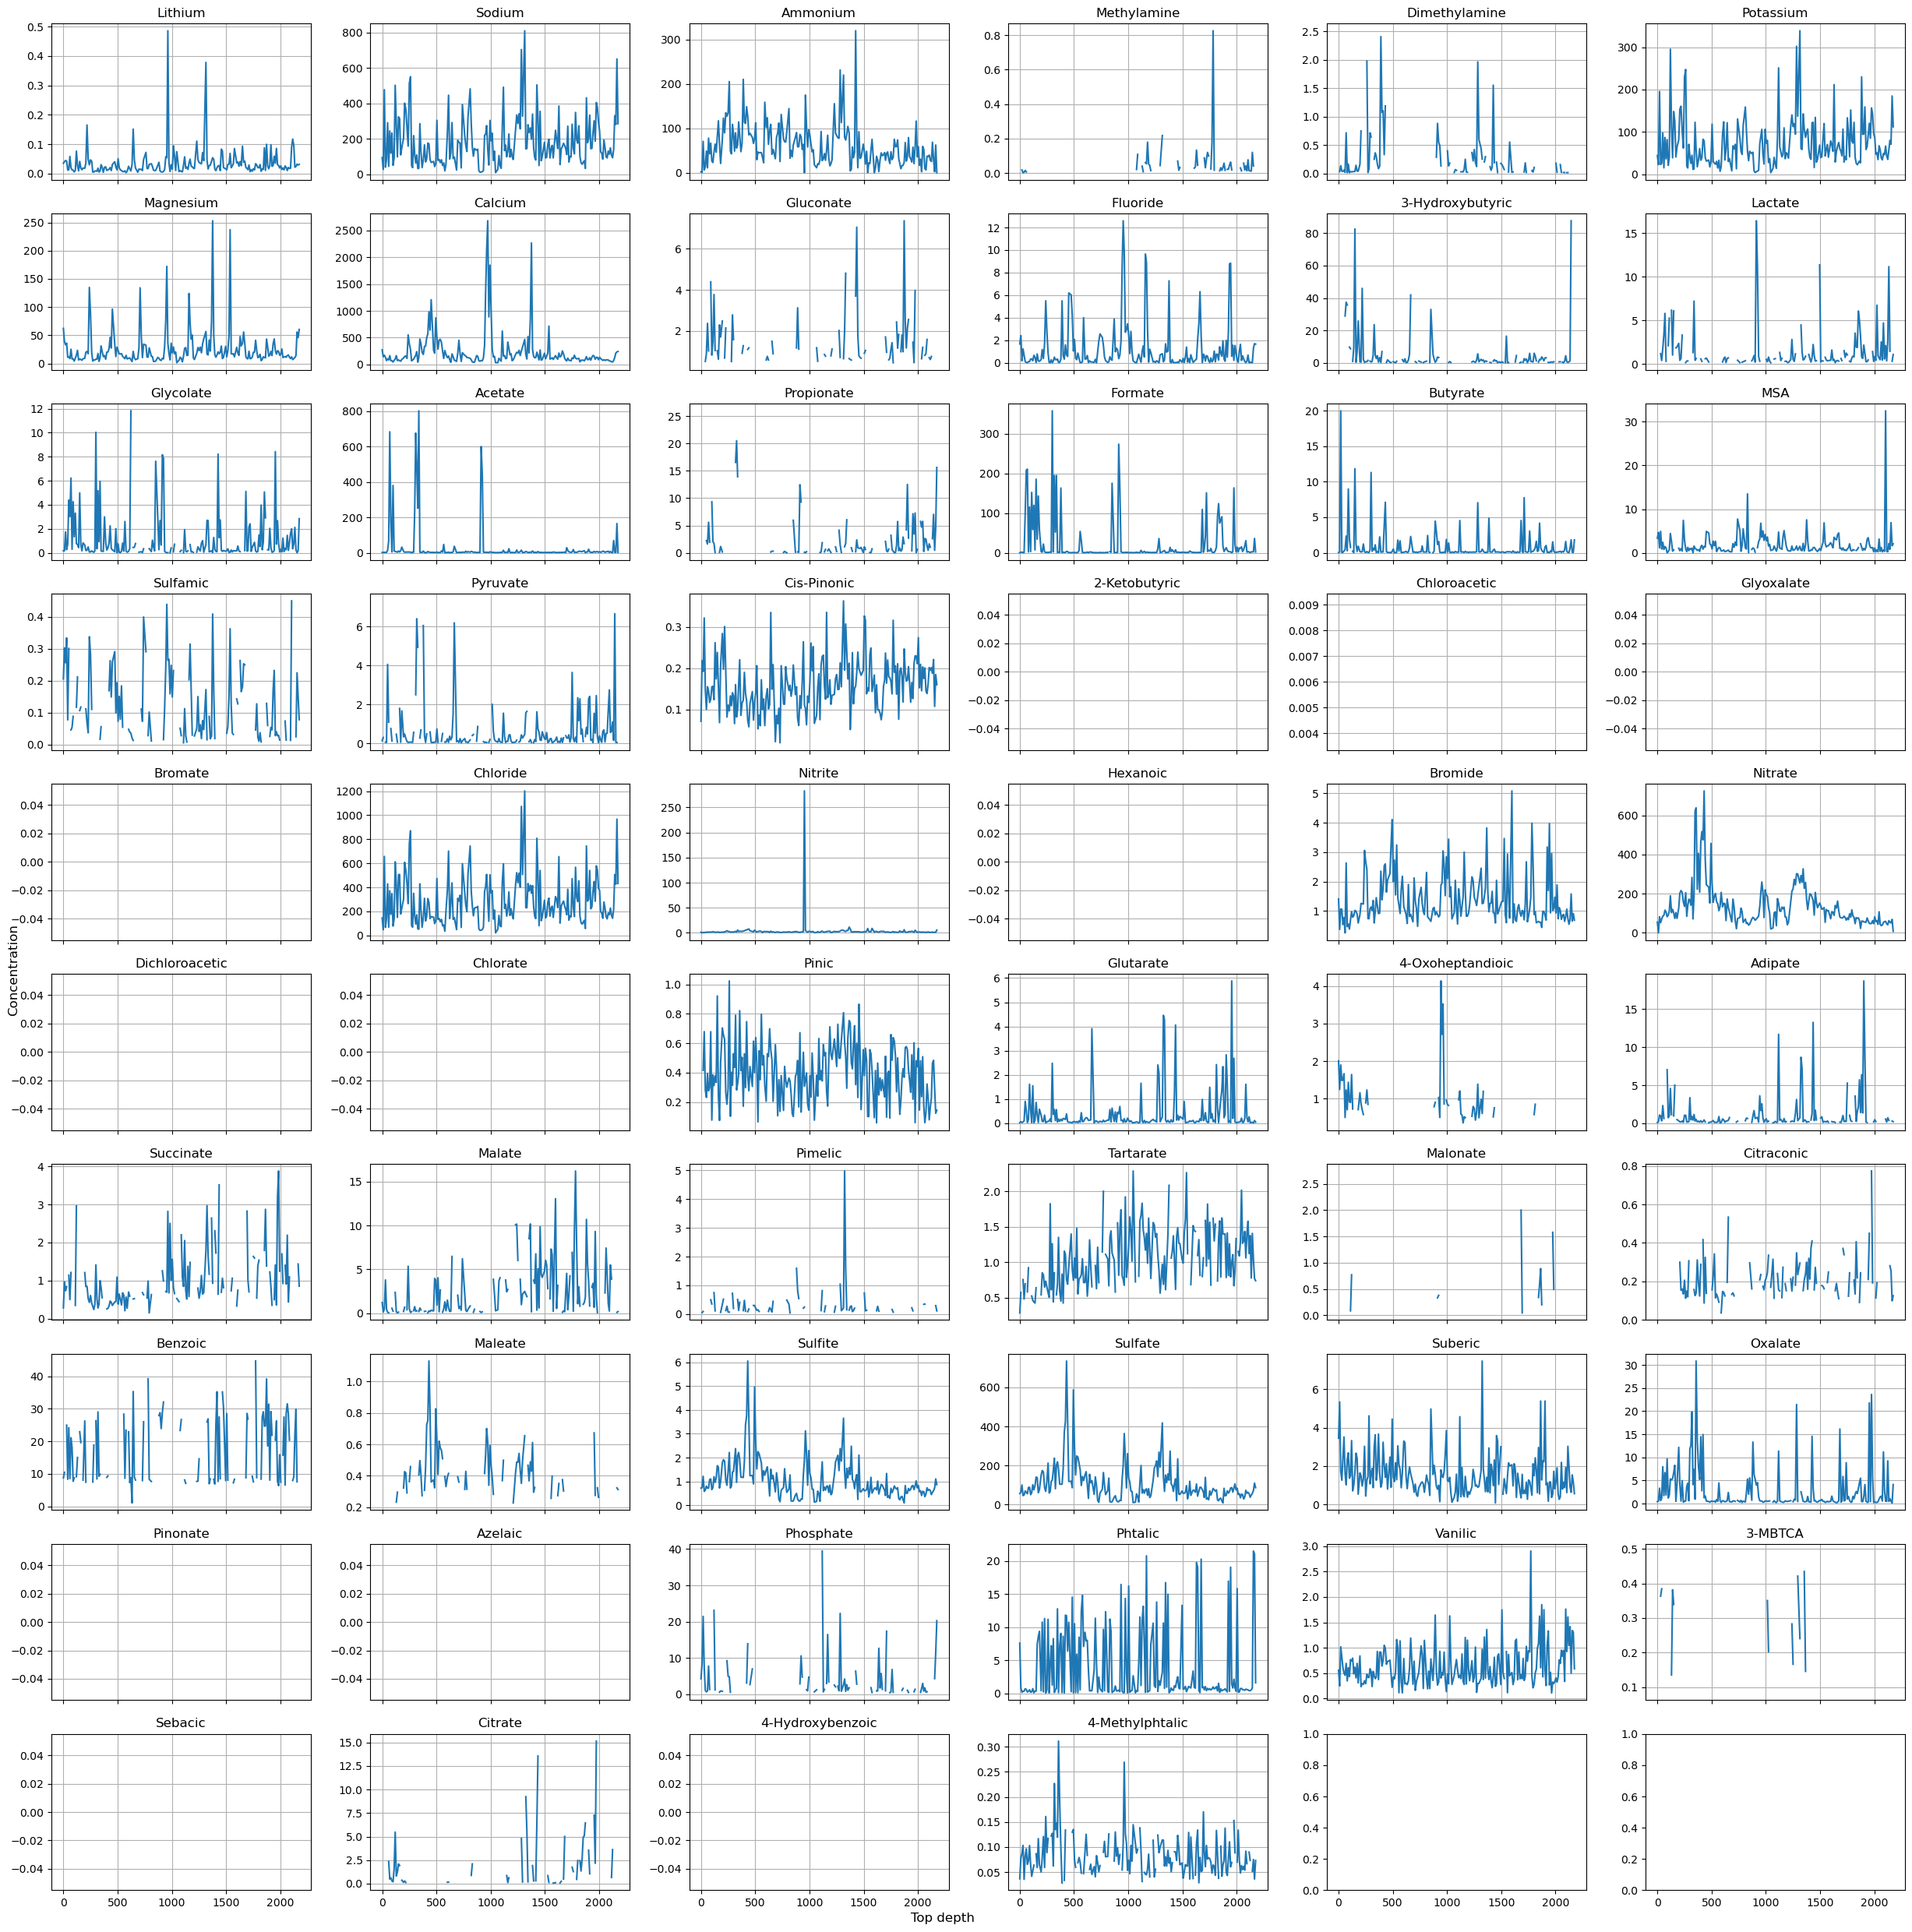

In [22]:
# Plot all chemistry data

cols = df_chem.columns[5:64]   # par ex. colonnes 9 à 18 (10 colonnes)

fig, axes = plt.subplots(10, 6, figsize=(25, 25), sharex=True, facecolor='white')

for ax, col in zip(axes.flat, cols):
    ax.plot(df_chem["Top depth"], df_chem[col])
    ax.set_title(col)
    ax.grid(True)

fig.supxlabel("Top depth")
fig.supylabel("Concentration")
plt.tight_layout()

figure_name = 'fig1.png'
plt.savefig(figure_name)

plt.show()

In [23]:
# Plot chemistry data of interest (selection by P. Ginot)
cols_chem = list(df_chem.columns[5:8]) \
     + list(df_chem.columns[11:13]) \
     + list(df_chem.columns[31:32]) \
     + list(df_chem.columns[34:35]) \
     + [df_chem.columns[50]]
df_chem['Conductivity'] = 0

In [24]:
cols_chem 

['Lithium',
 'Sodium',
 'Ammonium',
 'Magnesium',
 'Calcium',
 'Nitrite',
 'Nitrate',
 'Sulfate']

In [25]:
# Charges des majeurs
charge_ion = {
    'Lithium': 1,
    'Sodium': 1,
    'Ammonium': -1,
    'Magnesium': 2,
    'Calcium': 2,
    'Nitrite': -1,
    'Nitrate': -1,
    'Sulfate': -2
}

In [26]:
# Conductivité molaire de chaque ion (S·cm²/mol)
lambda_ion = {
    'Lithium': 38.7,
    'Sodium': 50.1,
    'Ammonium': 73.5,
    'Magnesium': 106,
    'Calcium': 119,
    'Nitrite': 71.6,
    'Nitrate': 71,
    'Sulfate': 160
}

In [27]:
for ion in cols_chem:
    df_chem['Conductivity'] += df_chem[ion] * charge_ion[ion]

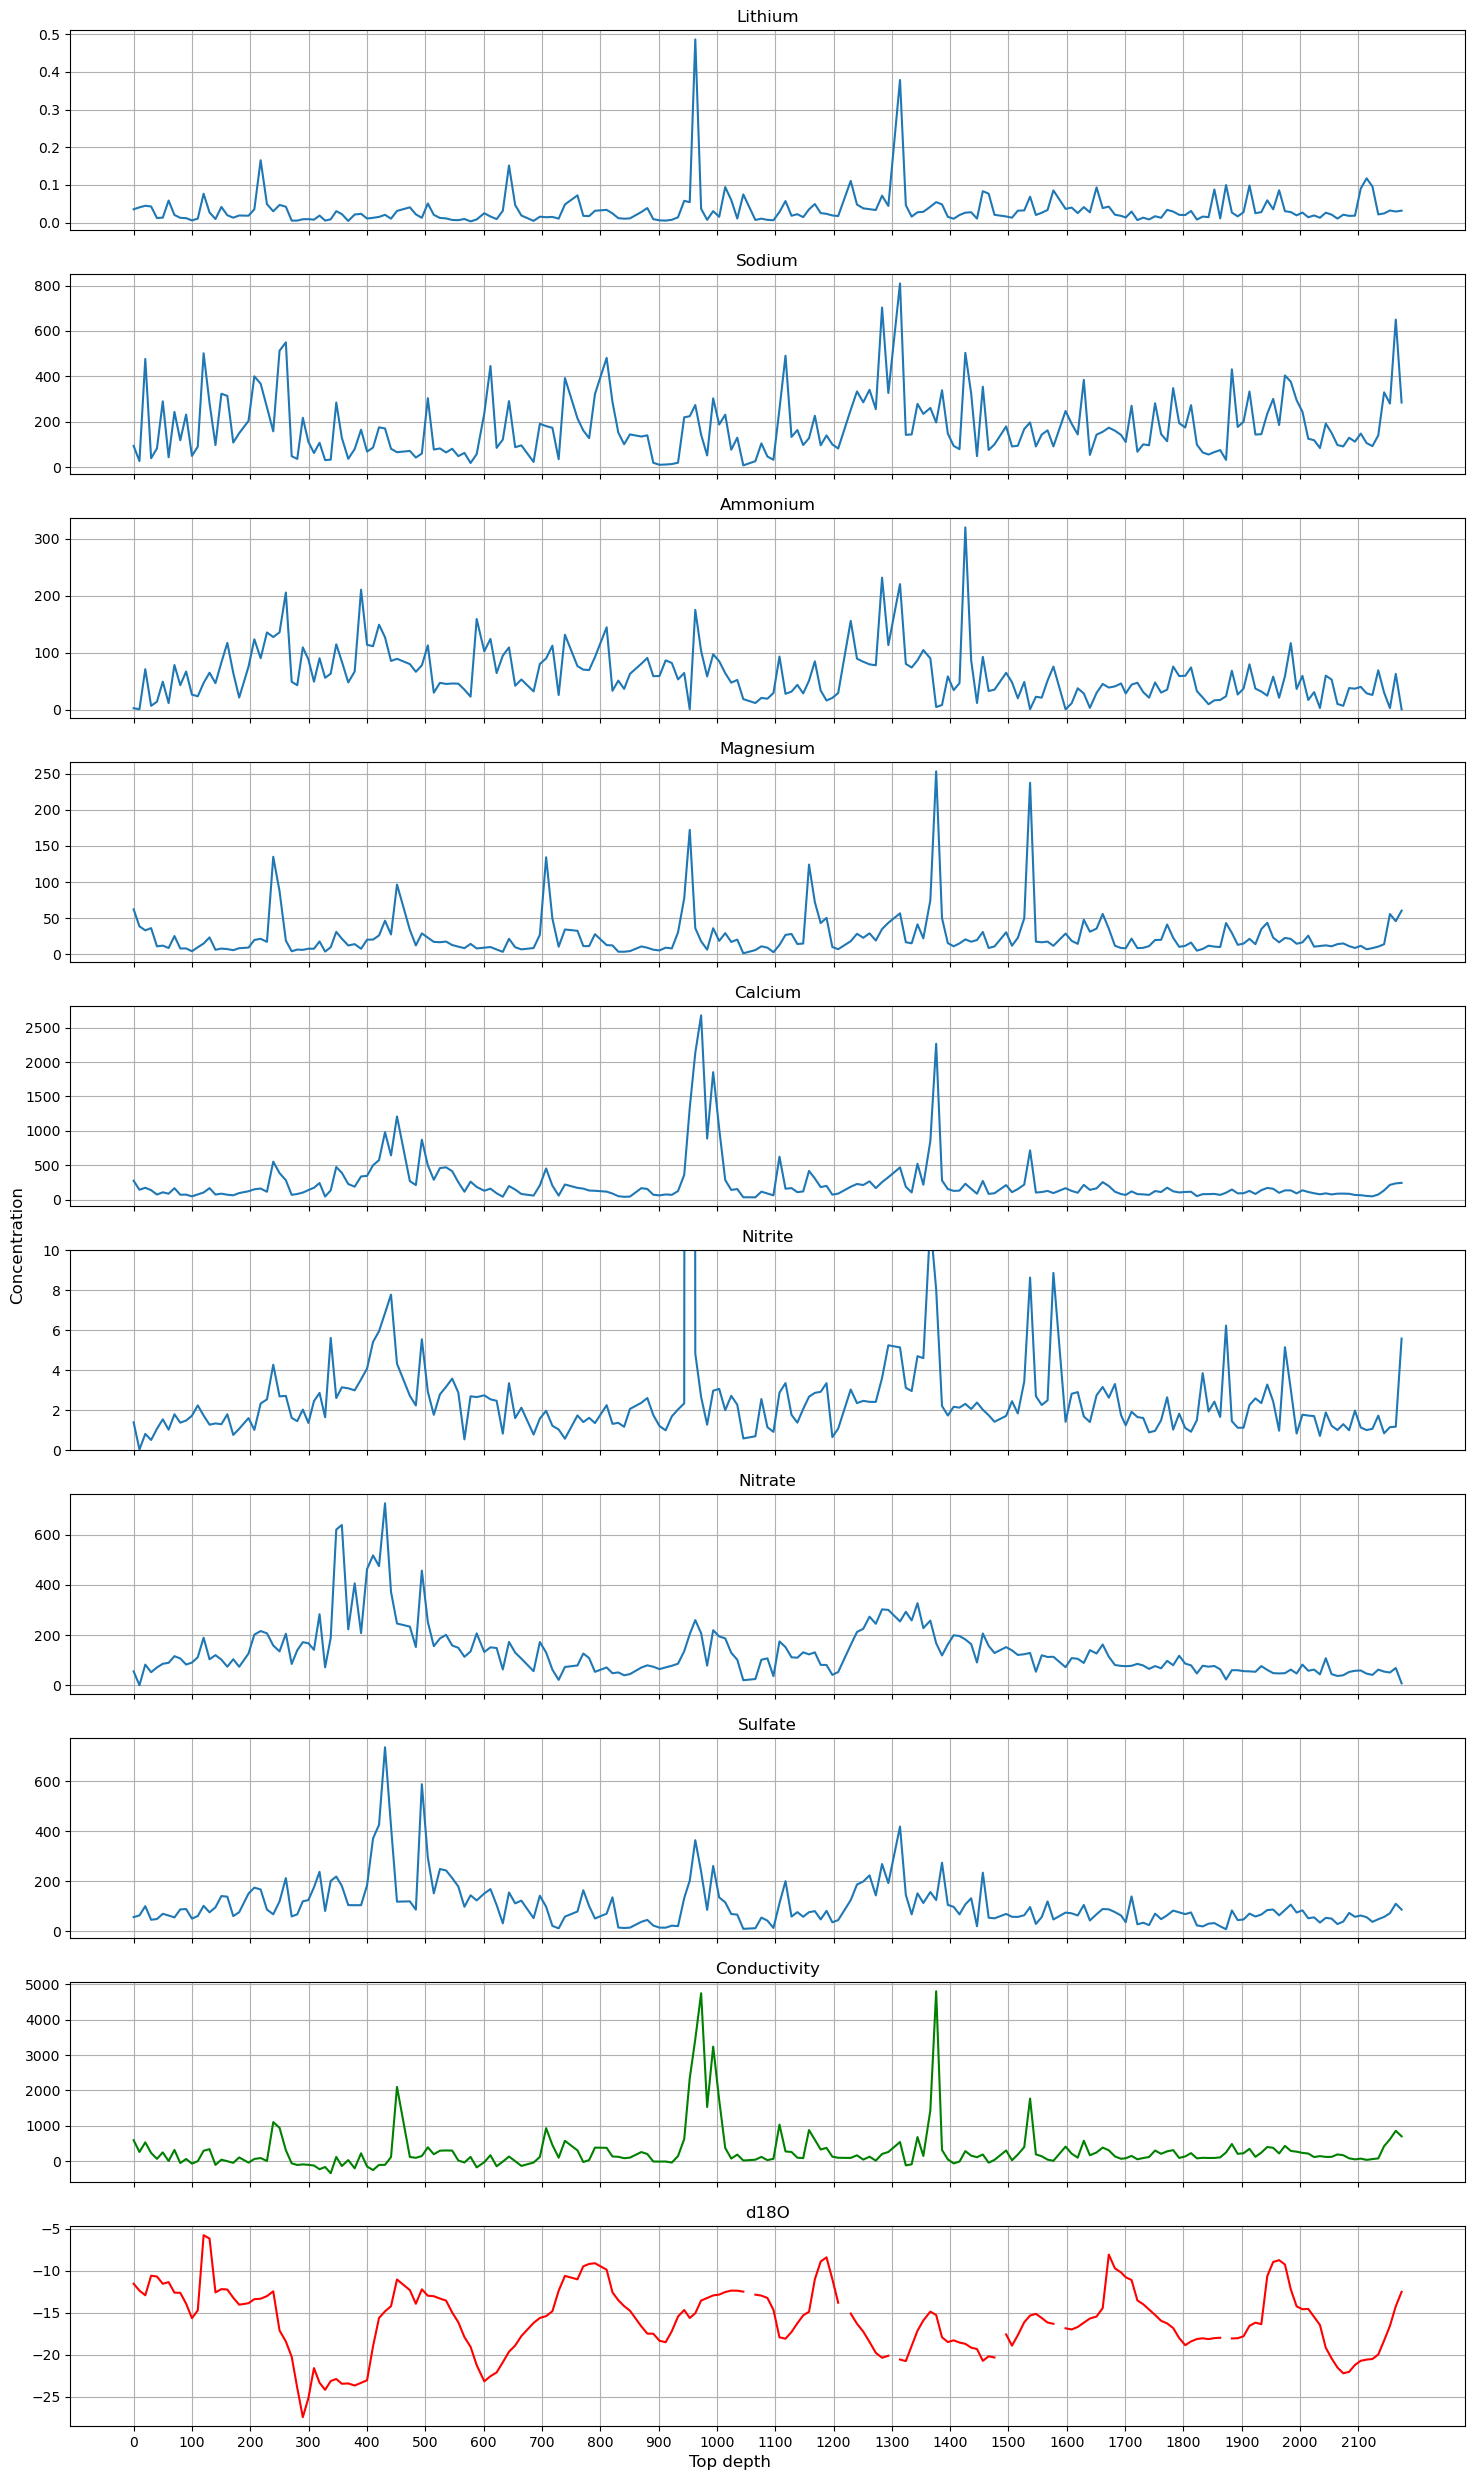

In [28]:
fig, axes = plt.subplots(10, 1, figsize=(15, 25), sharex=True, facecolor='white')

for ax, col in zip(axes.flat, cols_chem):
    ax.plot(df_chem["Top depth"], df_chem[col])
    ax.set_title(col)
    ax.grid(True)
    
axes[5].set_ylim(0, 10)

axes[8].plot(df_chem['Top depth'], df_chem['Conductivity'], color='green')
axes[8].grid(True)
axes[8].set_title('Conductivity')

axes[9].plot(df['Top depth'], df['Corrected Calibrated d(18_16) Mean'], color='red')
axes[9].grid(True)
axes[9].set_title('d18O')

xticks = np.arange(0, df_chem["Top depth"].max() + 1, 100)
axes[-1].set_xticks(xticks)

fig.supxlabel("Top depth")
fig.supylabel("Concentration")
plt.tight_layout()

figure_name = 'fig2.png'
plt.savefig(figure_name)


plt.show()

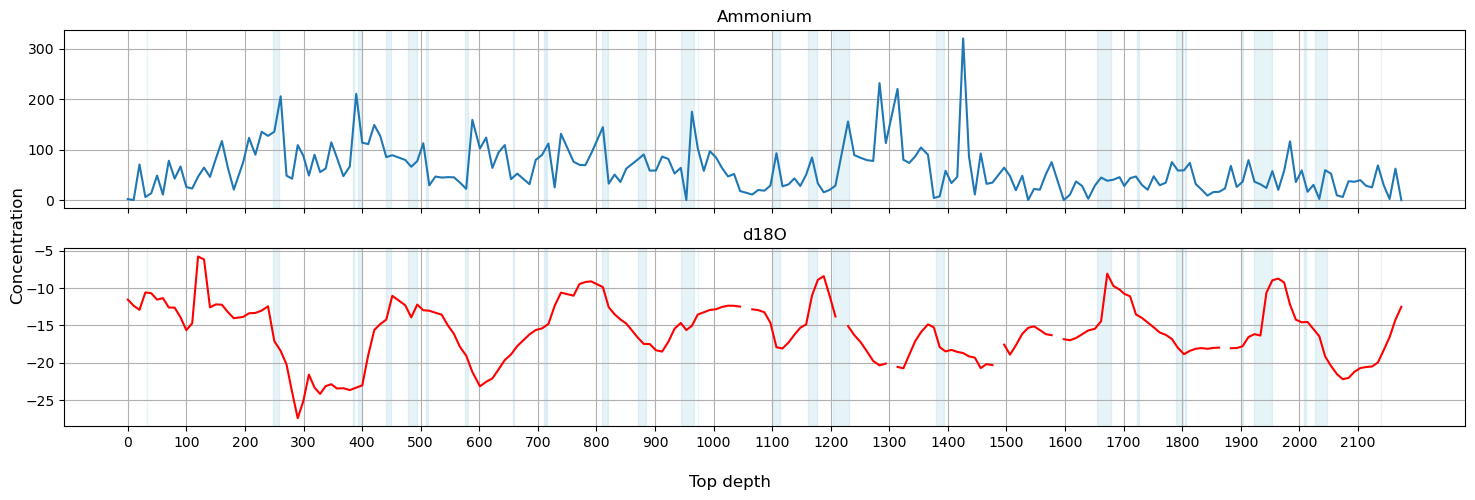

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(15, 5), sharex=True)

axes[0].plot(df_chem['Top depth'], df_chem['Ammonium'])
axes[0].grid(True)
axes[0].set_title('Ammonium')

axes[1].plot(df['Top depth'], df['Corrected Calibrated d(18_16) Mean'], color='red')
axes[1].grid(True)
axes[1].set_title('d18O')

xticks = np.arange(0, df_chem["Top depth"].max() + 1, 100)
axes[-1].set_xticks(xticks)

# Ice layers
for _, row in df_ice.iterrows():
    top = row["Top depth"]
    bottom = row["Bottom depth"]
    if pd.notna(top) and pd.notna(bottom) and bottom > top:
        axes[0].axvspan(top, bottom, color="lightblue", alpha=0.30, zorder=0)
        axes[1].axvspan(top, bottom, color="lightblue", alpha=0.30, zorder=0)

fig.supxlabel("Top depth")
fig.supylabel("Concentration")
plt.tight_layout()
plt.show()

In [32]:
segments_h2o = make_step_segments(df, "Corrected Calibrated d(18_16) Mean", "Top depth", "Bottom depth")
segments_mag = make_step_segments(df_chem, 'Magnesium', "Top depth", "Bottom depth")
segments_am = make_step_segments(df_chem, 'Ammonium', "Top depth", "Bottom depth")
segments_cond = make_step_segments(df_chem, 'Conductivity', "Top depth", "Bottom depth")
segments_ca = make_step_segments(df_chem, 'Calcium', "Top depth", "Bottom depth")
segments_li = make_step_segments(df_chem, 'Lithium', "Top depth", "Bottom depth")

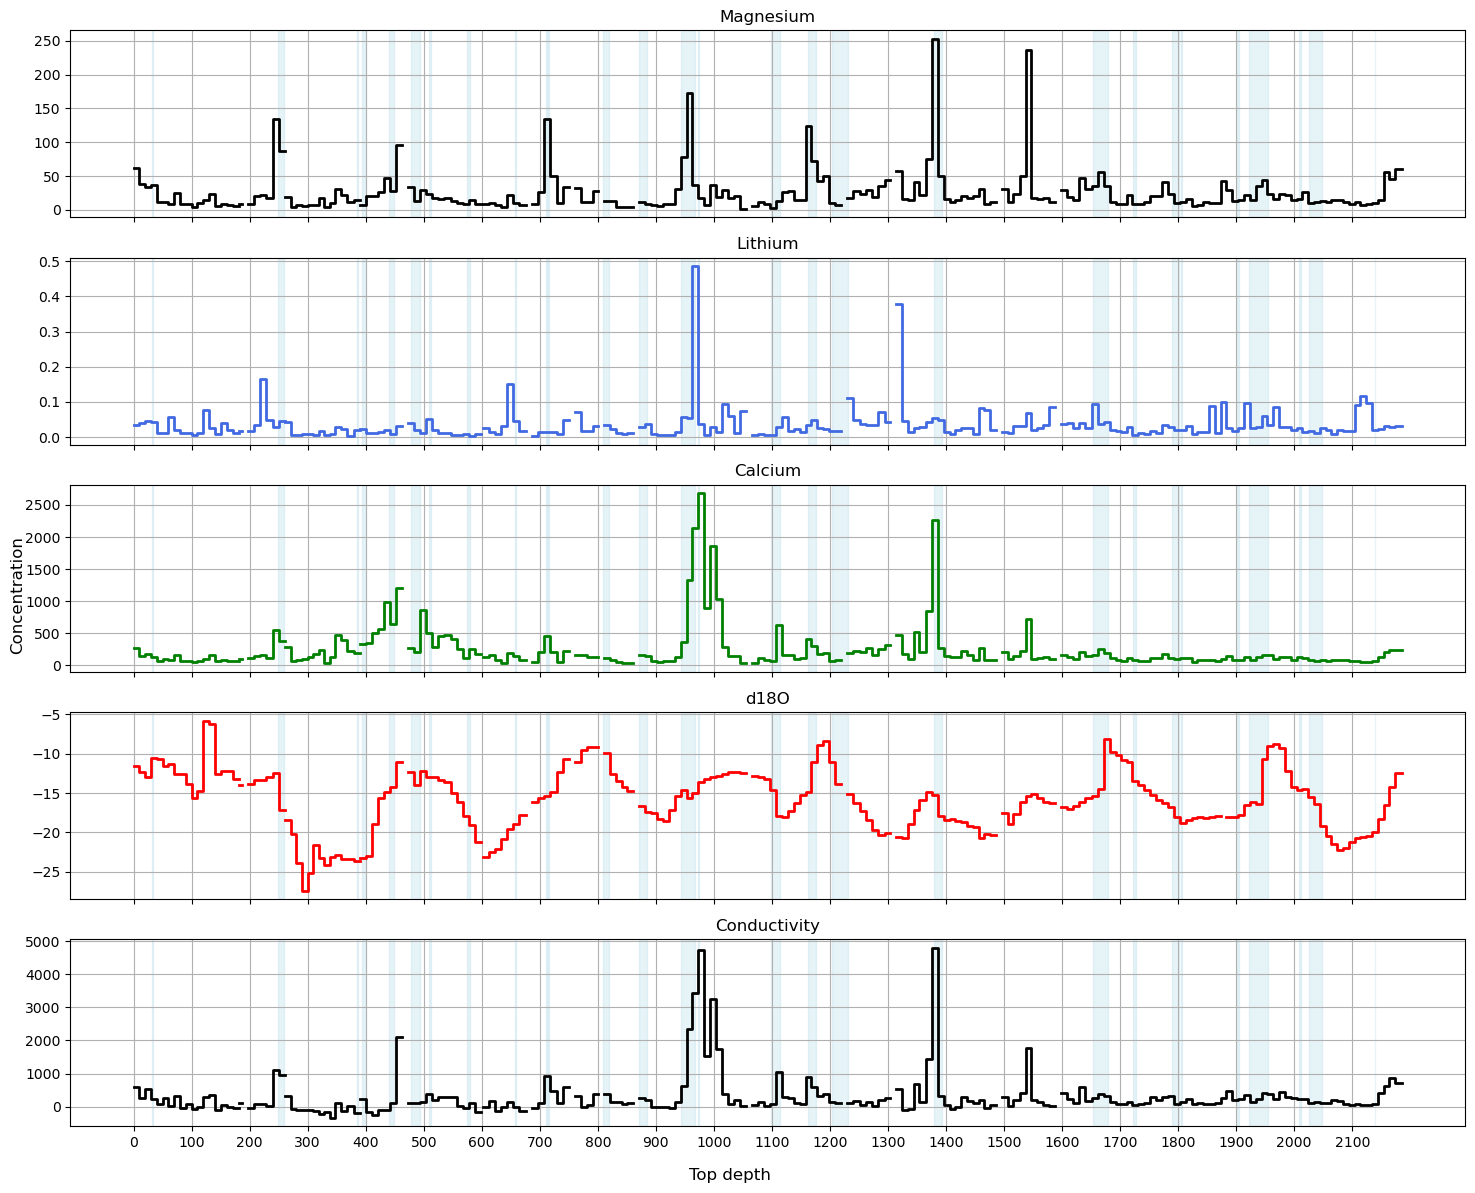

In [33]:
fig, axes = plt.subplots(5, 1, figsize=(15, 12), sharex=True, facecolor='white')

for values, depths in segments_mag:
    axes[0].plot(depths, values, color="black", linewidth=2, zorder=3)
    axes[0].grid(True)
    axes[0].set_title('Magnesium')

for values, depths in segments_li:
    axes[1].plot(depths, values, color="royalblue", linewidth=2, zorder=3)
    axes[1].grid(True)
    axes[1].set_title('Lithium')

for values, depths in segments_ca:
    axes[2].plot(depths, values, color="green", linewidth=2, zorder=3)
    axes[2].grid(True)
    axes[2].set_title('Calcium')

for values, depths in segments_h2o:
    axes[3].plot(depths, values, color="red", linewidth=2, zorder=3)
    axes[3].grid(True)
    axes[3].set_title('d18O')

for values, depths in segments_cond:
    axes[4].plot(depths, values, color="black", linewidth=2, zorder=3)
    axes[4].grid(True)
    axes[4].set_title('Conductivity')



# Ice layers
for _, row in df_ice.iterrows():
    top = row["Top depth"]
    bottom = row["Bottom depth"]
    if pd.notna(top) and pd.notna(bottom) and bottom > top:
        axes[0].axvspan(top, bottom, color="lightblue", alpha=0.30, zorder=0)
        axes[1].axvspan(top, bottom, color="lightblue", alpha=0.30, zorder=0)
        axes[2].axvspan(top, bottom, color="lightblue", alpha=0.30, zorder=0)
        axes[3].axvspan(top, bottom, color="lightblue", alpha=0.30, zorder=0)
        axes[4].axvspan(top, bottom, color="lightblue", alpha=0.30, zorder=0)

xticks = np.arange(0, df_chem["Top depth"].max() + 1, 100)
axes[-1].set_xticks(xticks)

fig.supxlabel("Top depth")
fig.supylabel("Concentration")
plt.tight_layout()

figure_name = 'fig3.png'
plt.savefig(figure_name)

plt.show()